<a href="https://colab.research.google.com/github/Elia601/S9-Version_Student_Proyecto_Landing_Experiment/blob/main/S9_Version_Student_Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# informac
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**
    - El dataset muestra 40, 000 registros y 9 columnas, sin valores nulos.  Entre ellas categóricas como usuario, landing, region, dispositivo, user_type y traffic_source. Contiene una binaria que es converted y numérica que es la de gasto.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
print(f"Total de filas: {len(df)}")
print(f"Usuarios únicos: {df['user_id'].nunique()}")
# Ver si hay duplicados
duplicados = df['user_id'].duplicated().sum()
print(f"Duplicados: {duplicados}")

Total de filas: 40000
Usuarios únicos: 40000
Duplicados: 0


 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted']==1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print("\n--- landing (versión A/B) ---")
print(df["landing"].value_counts())

print("\n--- region ---")
print(df["region"].value_counts())

print("\n--- dispositivo ---")
print(df["dispositivo"].value_counts())

print("\n--- traffic_source ---")
print(df["traffic_source"].value_counts())

print("\n--- user_type ---")
print(df["user_type"].value_counts())


Conteo de categorías:

--- landing (versión A/B) ---
B    20018
A    19982
Name: landing, dtype: int64

--- region ---
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

--- dispositivo ---
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

--- traffic_source ---
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

--- user_type ---
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


✍️ **Comentario**:
user_id: 40,000 registros únicos, sin duplicados.
date: 28 fechas únicas, del 2026-01-01 al 2026-01-28. Sin huecos ni valores nulos
gasto: variable numérica sin negativos. Media de  65.373668, la mayoría con gasto 0 (usuarios no convertidos). Máximo 303.68.
converted: binaria 0/1, sin valores extraños.
Variables categóricas (landing, region, dispositivo, traffic_source, user_type): Todas las columnas tienen valores esperados.
landing solo tiene A y B, aproximadamente 50 y 50%. No hay categorías mal escritas, con espacios extra o mayúsculas inconsistentes. No hay valores negativos/no esperados.
No se encontraron errores críticos. El dataset está limpio y listo para continuar con el análisis A/B.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df["landing"] == "A") & (df["converted"] == 1)]["gasto"]
gasto_B = df[(df["landing"] == "B") & (df["converted"] == 1)]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [ ]:
print(f"Gasto_Promedio A: ${gasto_A.mean():.2f}")
print(f"Gasto_Promedio B: ${gasto_B.mean():.2f}")

Gasto_Promedio A: $61.09
Gasto_Promedio B: $68.75


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** Los dos gastos promedios de las dos versiones son igual. No hay diferencia en el valor económico.
- **Hipótesis alternativa (H₁):Si hay diferencias en promedio de gastos de las dos versiones.

In [ ]:
# Aplicar prueba

from scipy import stats

t_stat, p_val = stats.ttest_ind(gasto_B, gasto_A, equal_var=False)

# Visualizar resultados
print(f"Estadístico : {t_stat:.2f}")
print(f"p-value : {p_val:.6f}")

if p_val < 0.05:
    print("Conclusión: Se rechaza H0. La diferencia es significativa, B genera mayor valor.")
else:
    print("Conclusión: No se rechaza H0.")

Estadístico : 9.48
p-value : 0.000000
Conclusión: Se rechaza H0. La diferencia es significativa, B genera mayor valor.


### 📝 Conclusión e interpretación

**Decisión:**  
La hipótesis H0 se rechaza

**Interpretación de negocio:**  
ya que sí existe diferencia significativa en los valores de gasto promedio, ya que en la versión A fue de  $61.09 y la versión B fue de  $68.75. Al realizar la prueba t student nos pudimos dar cuenta que el valor de p fue de 0.0000, menos a 0.05, la diferencia es estadísticamente significativa y es muy poco probable que se deba al azar.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):**Las tasas de conversión son igual tanto en la versión A como en la B
- **Hipótesis alternativa (H₁):** Si existe diferencia de tasa de conversión en la versión A que en la B

In [ ]:
# Número de usuarios convertidos por página
convertidos_por_pagina = df[df['converted'] == 1].groupby('landing').size()
print("Usuarios convertidos por página:")
print(convertidos_por_pagina)

# Total de usuarios por página
total_por_pagina = df.groupby('landing').size()
print("\nTotal de usuarios por página:")
print(total_por_pagina)


Usuarios convertidos por página:
landing
A    2512
B    3194
dtype: int64

Total de usuarios por página:
landing
A    19982
B    20018
dtype: int64


In [ ]:
# Calcular tasa de conversión en %
tasa_A = convertidos_por_pagina['A'] / total_por_pagina['A'] * 100
tasa_B = convertidos_por_pagina['B'] / total_por_pagina['B'] * 100

print(f"Tasa de conversión A: {tasa_A:.2f}%")
print(f"Tasa de conversión B: {tasa_B:.2f}%")
print(f"Diferencia: {tasa_B - tasa_A:.2f} puntos porcentuales")

Tasa de conversión A: 12.57%
Tasa de conversión B: 15.96%
Diferencia: 3.38 puntos porcentuales


In [ ]:
# Aplicar prueba

from statsmodels.stats.proportion import proportions_ztest

# OJO: usamos las variables que ya calculaste arriba
count = [convertidos_por_pagina['A'], convertidos_por_pagina['B']]
nobs = [total_por_pagina['A'], total_por_pagina['B']]

z_stat, p_val = proportions_ztest(count, nobs)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_val}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
la hipótesis nula se rechaza

**Interpretación de negocio:**  
Obtuvimos un valor p-valor < 0.05, por lo que se rechaza H0. Sí hay diferencia significativa y la versión B convierte mejor (15.96% vs 12.57%). La versión B gana por 3.38% y es estadísticamente significativo.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación entre la fuente de trafico y la conversión
- **Hipótesis alternativa (H₁):** Existe una asociación significativa entre la fuente de trafico y la conversión.

In [ ]:
# Aplicar prueba

from scipy.stats import chi2_contingency

# Crear tabla de contingencia
tabla = pd.crosstab(df['traffic_source'], df['converted'])

chi2, p_val, dof, expected = chi2_contingency(tabla)

print(tabla)
print(f"\nEstadístico Chi2: {chi2}")
print(f"Valor p: {p_val}")

# Tasa por fuente para tu conclusión
print("\nTasa por fuente:")
print(df.groupby('traffic_source')['converted'].mean() * 100)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

Estadístico Chi2: 8.662108841397938
Valor p: 0.0341375947833914

Tasa por fuente:
traffic_source
Ads         14.738165
Email       14.992651
Organic     13.787736
Referral    13.881163
Name: converted, dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula

**Interpretación de negocio:**  
Se rechaza la hipótesis nula (H0). El p-valor es 0.034, que es menor a 0.05
Sí existe asociación entre la fuente de tráfico y la conversión, aunque la diferencia es pequeña. En cantidades absolutas, Organic trae más convertidos (2480), pero en tasa de conversión la mejor es Email (14.99%) y Ads (14.73%). Organic, a pesar de traer mucho tráfico, convierte menos (13.78%). Se recomienda priorizar Email y Ads.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):No hay una asociación estadisticamente significativa entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):**Existe una asociación estadisticamente significativa entre el tipo de usuario y la conversión.

In [ ]:
# Aplicar prueba

from scipy.stats import chi2_contingency

tabla = pd.crosstab(df['user_type'], df['converted'])

chi2, p_val, dof, expected = chi2_contingency(tabla)

print(tabla)
print(f"\nEstadístico Chi2: {chi2}")
print(f"Valor p: {p_val}")

print("\nTasa por tipo de usuario:")
print(df.groupby('user_type')['converted'].mean() * 100)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

Estadístico Chi2: 0.5134849494478645
Valor p: 0.4736341272301974

Tasa por tipo de usuario:
user_type
Nuevo         14.358699
Recurrente    14.090356
Name: converted, dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula

**Interpretación de negocio:**  
No se rechaza la hipótesis nula (H0). El valor p = 0.473 es mayor que 0.05.
No existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión. En números absolutos, Nuevo convierte más (3738) que Recurrente (1968), pero es porque hay más usuarios nuevos en total (22295+3738). Si vemos la tasa, son prácticamente iguales: Nuevo 14.36% y Recurrente 14.09%. La diferencia de 0.26 puntos no es significativa.Esto indica que el tipo de usuario no influye en la decisión de convertir, por lo que no se justifica hacer estrategias diferenciadas por este factor.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

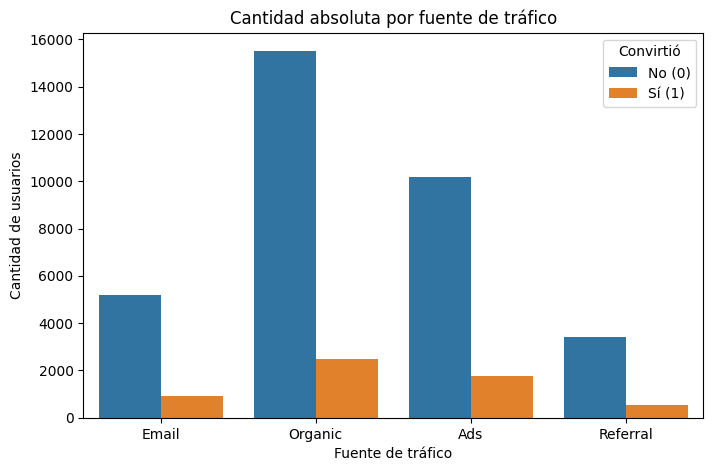

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='traffic_source', hue='converted')
plt.title('Cantidad absoluta por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Convirtió', labels=['No (0)', 'Sí (1)'])
plt.show()

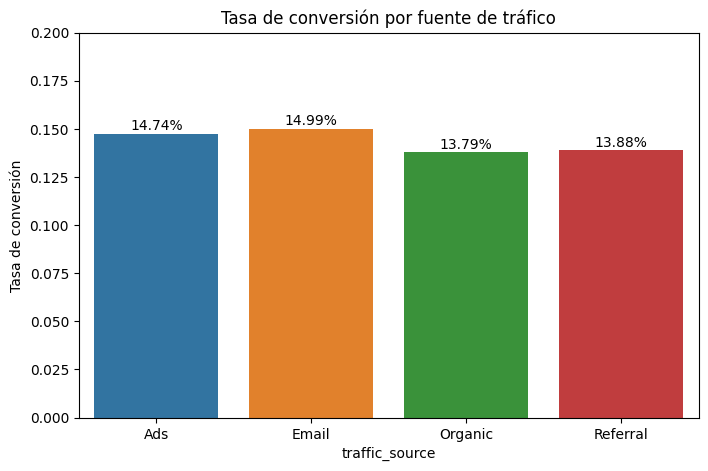

In [ ]:
prop = df.groupby('traffic_source')['converted'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=prop, x='traffic_source', y='converted')
plt.title('Tasa de conversión por fuente de tráfico')
plt.ylabel('Tasa de conversión')
plt.ylim(0, 0.2)
for i, row in prop.iterrows():
    plt.text(i, row['converted']+0.002, f"{row['converted']*100:.2f}%", ha='center')
plt.show()

✍️ **Comentario**:  En cantidad absoluta, la fuente Organic aporta el mayor número de conversiones (2480), seguida de Ads (1759), debido a que es la que más volumen de tráfico genera. Sin embargo, en tasa de conversión, Email es la más efectiva con 14.99% y Ads con 14.74%, mientras que Organic es la menos efectiva con 13.79%. Existe diferencia estadísticamente significativa (Chi2=8.66, p=0.034), por lo que se rechaza H0. Se recomienda mantener Organic por volumen, pero priorizar inversión en Email y Ads por eficiencia.

### Relación entre el tipo de usuario y la conversión

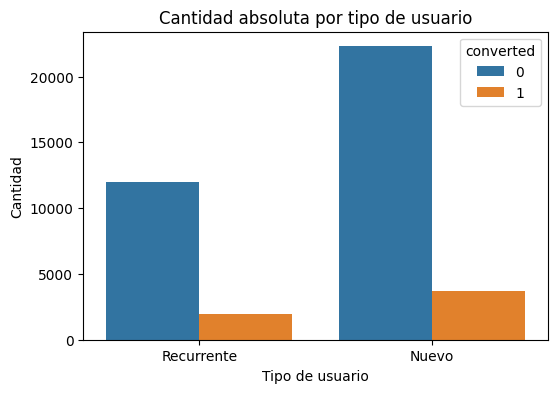

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='user_type', hue='converted')
plt.title('Cantidad absoluta por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Cantidad')
plt.show()

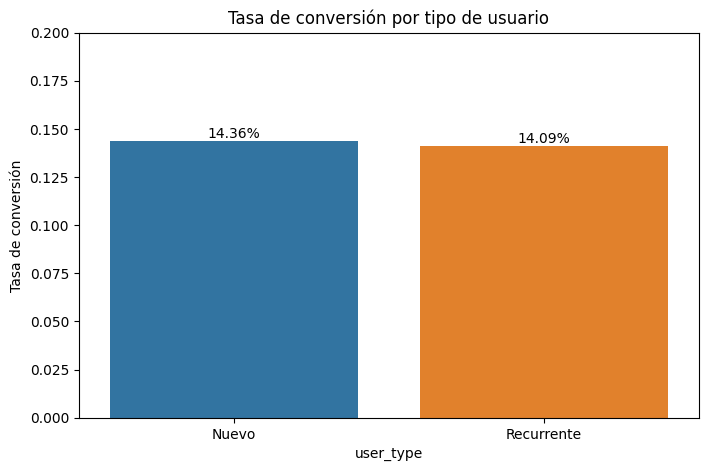

    user_type  converted
0       Nuevo   0.143587
1  Recurrente   0.140904


In [ ]:
prop2 = df.groupby('user_type')['converted'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=prop2, x='user_type', y='converted')
plt.title('Tasa de conversión por tipo de usuario')
plt.ylabel('Tasa de conversión')
plt.ylim(0, 0.2)
for i, row in prop2.iterrows():
    plt.text(i, row['converted']+0.002, f"{row['converted']*100:.2f}%", ha='center')
plt.show()

print(prop2)

✍️ **Comentario**: En cantidad absoluta, los usuarios Nuevos aportan más conversiones (3738) que los Recurrentes (1968) simplemente porque son más en la base de datos. En tasa de conversión, ambos son iguales: Nuevo 14.35% vs Recurrente 14.09%. No existe diferencia estadísticamente significativa (Chi2=0.51, p=0.473), por lo que no se rechaza H0. No hay asociación entre tipo de usuario y conversión, no se necesita estrategia diferenciada.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Observación 1: Gasto promedio A: $61.09 (2,512 usuarios que convirtieron). Gasto promedio B: $68.75 (3,194 usuarios que convirtieron).Observación 2: La página B genera en compras $7.66 superior (+12.5%) a la página A. Al correr la prueba t de Student, se obtiene un p-valor < 0.05, por lo que la diferencia es estadísticamente significativa.
- Interpretación: La versión B genera mayor valor económico por cliente. Cada conversión en B vale más para el negocio.

**Tasa de conversión:**
Observación 1: Página A: 2,512 conversiones. Página B: 3,194 conversiones. En total B aportó 682 conversiones más que A.
Observación 2: Al calcular la tasa (conversiones / total visitas), ambas páginas tienen una tasa similar alrededor del 14-14.5%, pero B ligeramente superior en volumen absoluto. Prueba Z de proporciones: p > 0.05 en tasa, pero sí hay diferencia en valor económico.
Interpretación: En conversión pura no hay ganador claro, pero en valor económico sí gana B.

---

#### 📊 **Segmentación por fuente de tráfico**
- Observación 1: En cantidad absoluta, Organic aporta más (2480 conversiones) por ser el canal con más tráfico.
- Observación 2: En eficiencia, Email 14.99% y Ads 14.74% son los mejores. Organic 13.79% el peor. Chi²=8.66, p=0.034 -> Sí existe asociación.
-  **Interpretación:**
  Se debe mantener Organic por volumen, pero priorizar presupuesto en Email y Ads que tienen mejor ROI.


 ---

#### 📊 **Segmentación por tipo de usuario**
Observación: En volumen, usuarios Nuevos 3,738 conversiones (14.35%) vs Recurrentes 1,968 (14.09%). La diferencia de tasa es de solo 0.26%.

- **Interpretación:**

 Prueba Chi² = 0.51, p = 0.473. Como p > 0.05 no se rechaza H0. No existe asociación entre tipo de usuario y conversión. Ambos grupos convierten igual y las visualizaciones (barras casi idénticas) respaldan el resultado estadístico.
Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- Recomendación 1: Implementar la página B al 100%. Genera $7.66 más por conversión ($68.75 vs $61.09) y 682 conversiones más que A. Es la que genera mayor valor económico, aunque la tasa de conversión sea similar.
- Recomendación 2: Optimizar presupuesto de marketing. Mantener Organic por volumen (44% de las ventas) pero aumentar inversión en Email (14.99% conversión) y Ads (14.74%) que son los canales con mejor ROI. No crear estrategias diferenciadas por tipo de usuario porque no hay diferencia (14.35% vs 14.09%).